# Sample Notebook for Observation error stuff in dapyr

In [3]:
import numpy as np
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from DAPyr.OBS_ERRORS import sample_errors, get_likelihood
from scipy.stats import norm

reload(dap)


<module 'DAPyr' from '/Users/aosc/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py'>

In [14]:
xf = np.loadtxt('../tests/states/xf.txt', delimiter = ',')
Y = np.loadtxt('../tests/states/Y.txt', delimiter = ',')

(40, 20)
(40,)


In [6]:
true_obs_params = {'mu' : 0, 'sigma': 1}
true_obs_dist = 0
assumed_obs_params = {'mu1': -2.0, 'sigma1': 1, 'mu2': 3.0, 'sigma2':.5, 'threshold': 0}
assumed_obs_dist = 1
rng = np.random.default_rng(58)
xt = rng.normal(size=(40,20))
xf = rng.normal(size=(40,20))

Y = xt + sample_errors(xt, true_obs_dist, true_obs_params, rng)
Y = Y[:,0]

L = dap.OBS_ERRORS.get_likelihood(assumed_obs_dist, assumed_obs_params)
Nx, Ne = xf.shape
Ny = Nx
H = np.eye(Nx)
C = np.ones((Nx, Nx))
e_flag = 0
qcpass = np.zeros((Ny,))
xm = np.mean(xf, axis = -1)[:, None]

N_eff = 0.4
kddm_flag = 0
maxiter = 1
alpha = 0.3
min_res = 0.0
xa, e_flag = dap.DA.lpf_update(xf, xf, Y[:, None], H, C, N_eff*Ne, alpha, 
                               min_res, maxiter, kddm_flag, e_flag, qcpass, L)


In [7]:
#dap.runDA(e_assumed_sdg)
#xa = e_assumed_sdg.x_ens
#np.savetxt('xa_assumed_obs_error_sd_gaussian', xa.flatten(), delimiter=',')

poep = {'mu':0, 'sigma':1}
poep_wrong = {'mu':0, 'sigma':2}

In [10]:
e_name='test'

e_gaus_good = dap.Expt(e_name, {'expt_flag': 0,
                       'model_flag':1,
                       'localize':1,
                       'obf': 1,
                       'seed': 1,
                       'qc_flag': 0,
                       'true_obs_err_dist': 0,
                       'assumed_obs_err_dist': 0,
                       'true_obs_err_params': poep,
                       'assumed_obs_err_params': poep,
                       'Ne':80,
                       'T': 2000})

e_gaus_bad = dap.Expt(e_name, {'expt_flag': 0,
                       'model_flag':1,
                       'localize':1,
                       'obf': 1,
                       'seed': 1,
                       'qc_flag': 0,
                       'true_obs_err_dist': 0,
                       'assumed_obs_err_dist': 0,
                       'true_obs_err_params': poep,
                       'assumed_obs_err_params': poep_wrong,
                       'Ne':80,
                       'T': 2000})


In [11]:
dap.runDA(e_gaus_good)
dap.runDA(e_gaus_bad)

DB: Starting cycle 0
DB: Starting cycle 50
DB: Starting cycle 100
DB: Starting cycle 150
DB: Starting cycle 200
DB: Starting cycle 250
DB: Starting cycle 300
DB: Starting cycle 350
DB: Starting cycle 400
DB: Starting cycle 450
DB: Starting cycle 500
DB: Starting cycle 550
DB: Starting cycle 600
DB: Starting cycle 650
DB: Starting cycle 700
DB: Starting cycle 750
DB: Starting cycle 800
DB: Starting cycle 850
DB: Starting cycle 900
DB: Starting cycle 950
DB: Starting cycle 1000
DB: Starting cycle 1050
DB: Starting cycle 1100
DB: Starting cycle 1150
DB: Starting cycle 1200
DB: Starting cycle 1250
DB: Starting cycle 1300
DB: Starting cycle 1350
DB: Starting cycle 1400
DB: Starting cycle 1450
DB: Starting cycle 1500
DB: Starting cycle 1550
DB: Starting cycle 1600
DB: Starting cycle 1650
DB: Starting cycle 1700
DB: Starting cycle 1750
DB: Starting cycle 1800
DB: Starting cycle 1850
DB: Starting cycle 1900
DB: Starting cycle 1950
DB: Starting cycle 0
DB: Starting cycle 50
DB: Starting cycle 1

'completed'

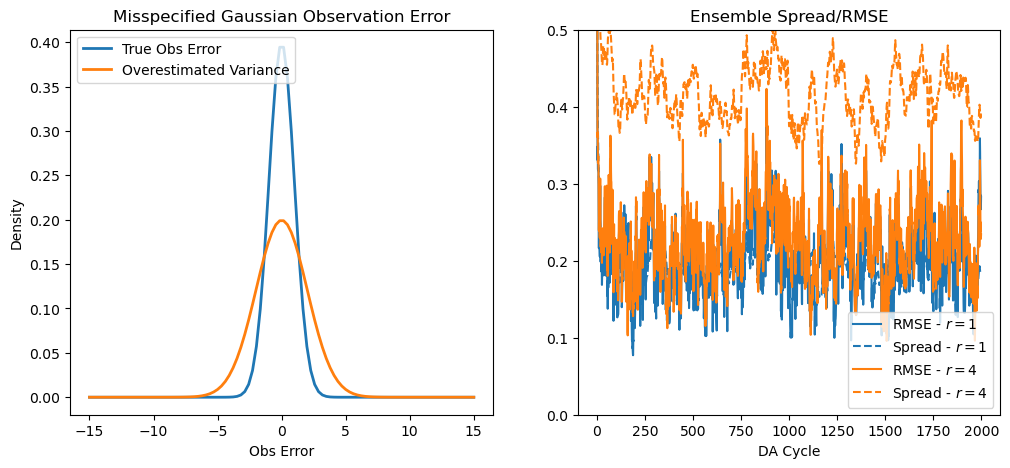

In [12]:
fig, axs = plt.subplots(1,2, figsize=(12,5), sharey='col', sharex='col')
axs[1].set_title('Ensemble Spread/RMSE')
axs[1].plot(e_gaus_good.rmse, label='RMSE - $r=1$', c='C0')
axs[1].plot(e_gaus_good.spread[:,1], linestyle='dashed', c='C0',  label='Spread - $r=1$')
axs[1].plot(e_gaus_bad.rmse, label='RMSE - $r=4$', c='C1')
axs[1].plot(e_gaus_bad.spread[:,1], linestyle='dashed', c='C1',  label='Spread - $r=4$')
axs[1].legend()
axs[1].set_xlabel('DA Cycle')
axs[1].set_ylim(0,0.5)
axs[1].set_ylabel('')

axs[0].set_title('Misspecified Gaussian Observation Error')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=0, scale=1), linewidth=2, c='C0', label='True Obs Error')
axs[0].plot(np.linspace(-15, 15, 100), norm.pdf(np.linspace(-15, 15, 100), loc=0, scale=2), linewidth=2, c='C1', label='Overestimated Variance')
axs[0].set_ylabel('Density')
axs[0].set_xlabel('Obs Error')
axs[0].legend(loc=2)


plt.savefig('badgaussdemo.png')
plt.show()



In [37]:
a = np.vstack([np.arange(5)+1 * (i+1) for i in range(5)])/9
b = np.vstack([np.arange(5)+1 * (i+1) for i in range(5)])/9
for i in range(5):
    for j in range(5):
        if i + j < 4:
            b[i,j]=.11
        if i + j > 4:
            b[i,j]=1
print(a)

[[0.11111111 0.22222222 0.33333333 0.44444444 0.55555556]
 [0.22222222 0.33333333 0.44444444 0.55555556 0.66666667]
 [0.33333333 0.44444444 0.55555556 0.66666667 0.77777778]
 [0.44444444 0.55555556 0.66666667 0.77777778 0.88888889]
 [0.55555556 0.66666667 0.77777778 0.88888889 1.        ]]


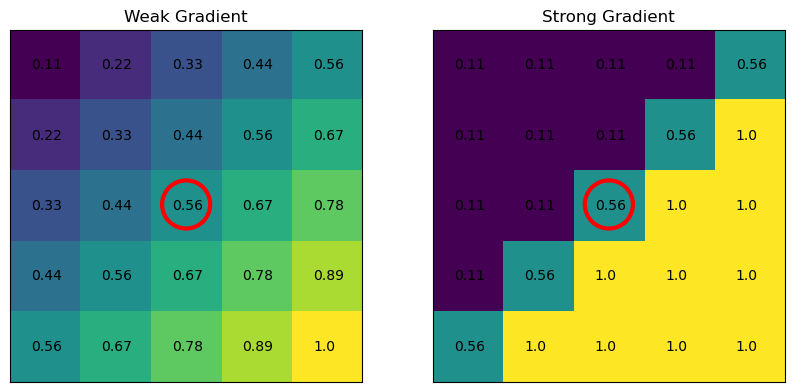

In [42]:

fig, axs = plt.subplots(1,2, figsize=(10,10))

for i in range(5):
    for j in range(5):
        axs[0].text(i-.2,j + .05,np.round(a[i,j],2))
        axs[1].text(i-.2,j + .05,np.round(b[i,j],2))

        

axs[0].set_title('Weak Gradient')
axs[0].imshow(a)
axs[0].scatter(2,1.98, edgecolors='r', facecolor='none', s=1200, linewidths=3)
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].set_title('Strong Gradient')
axs[1].imshow(b)
axs[1].scatter(2,1.98, edgecolors='r', facecolor='none', s=1200, linewidths=3)
axs[1].set_xticks([])
axs[1].set_yticks([])
plt.savefig('kecdgrads.png')

/var/folders/8j/k_hxvb2s6ts__zmjbc2qn9q80000gn/T/ipykernel_28416/2409561556.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posnorm = np.trapz(posterior_pdf, x)


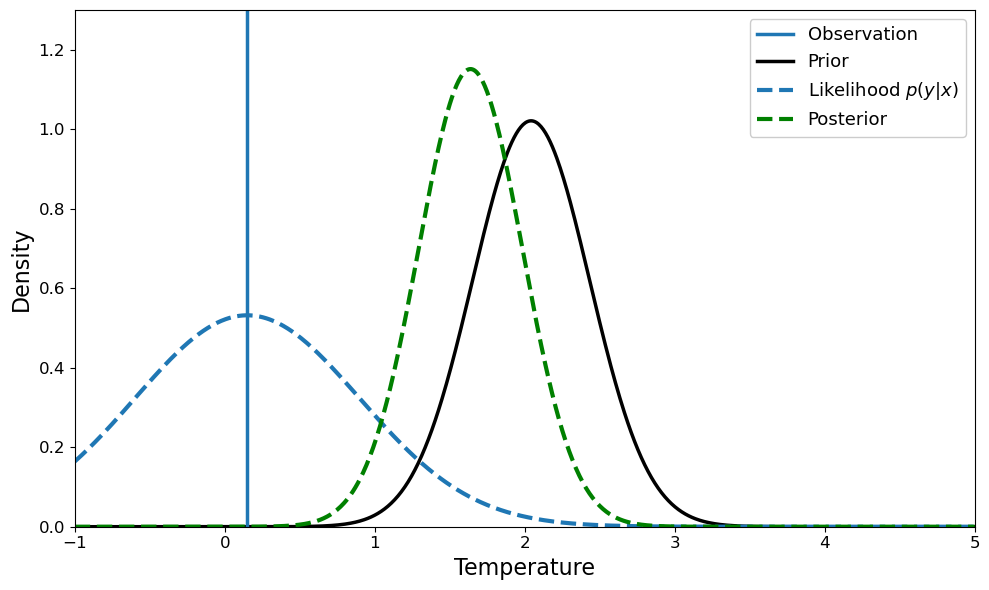

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

# -----------------------------
# Deterministic setup
# -----------------------------

# Match figure aspect (≈1000x600 px)
fig, ax = plt.subplots(figsize=(10, 6))

rng = np.random.default_rng(0)

# -----------------------------
# Continuous grid
# -----------------------------
x = np.linspace(-1, 5, 800)

# -----------------------------
# Prior particles (black dots + stems)
# -----------------------------
#prior_particles = np.array([0.35, 0.55, 0.70, 0.85, 1.00, 1.15, 1.35, 2.10, 2.25]) + 1
prior_particles = rng.normal(2, 0.5, size=10)
#ax.stem(
#    prior_particles,
#    np.full_like(prior_particles, 0.10),
#    linefmt='k-',
#    markerfmt='ko',
#    basefmt=' ',
#)

pmean = prior_particles.mean()
pvar = prior_particles.std(ddof=1)

# -----------------------------
# Prior (black, right-skewed)
# -----------------------------
prior = norm(loc=pmean, scale=pvar)
prior_pdf = prior.pdf(x)
ax.plot(x, prior_pdf, color='black', lw=2.5)


# -----------------------------
# Observation (blue vertical line)
# -----------------------------
y_obs = 0.15
ax.axvline(y_obs, color='#1f77b4', lw=2.5)

# -----------------------------
# Likelihood p(y|x) (blue dashed)
# -----------------------------
sigma_obs = 0.75
likelihood = norm(loc=y_obs, scale=sigma_obs)
ax.plot(
    x,
    likelihood.pdf(x),
    linestyle='--',
    color='#1f77b4',
    lw=3
)

# -----------------------------
# Posterior (green dashed)
# -----------------------------
posterior_pdf = prior_pdf * likelihood.pdf(x)
posnorm = np.trapz(posterior_pdf, x)
posterior_pdf /= posnorm
ax.plot(
    x,
    posterior_pdf,
    linestyle='--',
    color='green',
    lw=3
)

# -----------------------------
# Posterior particles (green dots + stems)
# -----------------------------
posterior_particles = (y_obs * pvar **2 + prior_particles * sigma_obs **2) / (sigma_obs **2 + pvar **2)
#ax.stem(
#    posterior_particles,
#    np.full_like(posterior_particles, 0.1),
#    linefmt='g-',
#    markerfmt='go',
#    basefmt=' ',
#)

    #prior.pdf(posterior_particles) * likelihood.pdf(posterior_particles) / posnorm,

# -----------------------------
# Axes, limits, labels
# -----------------------------
ax.set_xlim(-1, 5)
ax.set_ylim(0, 1.3)

ax.set_xlabel("Temperature", fontsize=16)
ax.set_ylabel("Density", fontsize=16)

ax.tick_params(axis='both', labelsize=12)

# -----------------------------
# Legend (order & style matched)
# -----------------------------
legend_handles = [
#    plt.Line2D([], [], color='k', marker='o', linestyle='None',
#               markersize=8, label='Prior Ensemble'),
    plt.Line2D([], [], color='#1f77b4', lw=2.5, label='Observation'),
    plt.Line2D([], [], color='k', lw=2.5, label='Prior'),
    plt.Line2D([], [], color='#1f77b4', lw=3, linestyle='--',
               label=r'Likelihood $p(y|x)$'),
    plt.Line2D([], [], color='green', lw=3, linestyle='--',
               label=r'Posterior'),
#    plt.Line2D([], [], color='green', marker='o', linestyle='None',
#               markersize=8, label='Posterior Ensemble'),
]

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=True,
    framealpha=1,
    fontsize=13
)

#plt.plot([pmean-pvar, pmean+pvar], [.6,.6], c='k')

plt.tight_layout()

plt.savefig('dademo.png')

plt.show()


In [62]:
print(prior_particles.mean())
print(prior_particles.std(ddof=1))

1.1444444444444444
0.6583333333333333


0.75

np.float64(0.9959027777777778)